RQ1: Can introducing semantically valid, artificially crafted, and maliciously altered network flow perturbations, creating the effects of a network poisoning attack, into an IDS training dataset, such as the Unified Multimodal NIDS CIC-IDS2019 dataset, reduce the robustness of the training of the model?

H10: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has no statistically significant effect on the model's overall performance.

H1a: Using bootstrap resampling to estimate precision, recall, and FPR with 95% confidence intervals, introducing perturbations to the model’s training dataset has a statistically significant effect on the model's overall performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import resample
from xgboost import XGBClassifier

In [2]:
df_sample = pd.read_csv("clean_sample_150000.csv")

In [3]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))

In [4]:
def base_xgb(): return XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.03, eval_metric="mlogloss", random_state=42, tree_method="hist")

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train = X_train.astype("float32")
X_test = X_test.astype("float32")
y_test = y_test.reset_index(drop=True).to_numpy()
model = base_xgb()
model.fit(X_train, y_train, eval_set=[(X_train, y_train), (X_test, y_test)], verbose=False)

,objective,'multi:softprob'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'mlogloss'


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Weighted F1:", f1_score(y_test, y_pred, average='weighted'))
print("Macro F1:", f1_score(y_test, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y_test, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.9073333333333333
Weighted F1: 0.9071898184339834
Macro F1: 0.9071898184339834
ROC-AUC: 0.9828639566666667


In [7]:
print(classification_report(y_test, y_pred, target_names=le.classes_))

                precision    recall  f1-score   support

        BENIGN       1.00      1.00      1.00     10000
    DoS_ATTACK       0.89      0.82      0.86     10000
NON_DoS_ATTACK       0.84      0.90      0.87     10000

      accuracy                           0.91     30000
     macro avg       0.91      0.91      0.91     30000
  weighted avg       0.91      0.91      0.91     30000



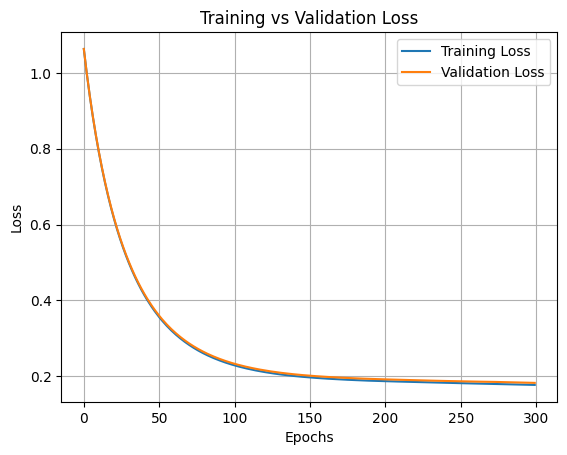

In [8]:
results = model.evals_result()
train_loss = results['validation_0']['mlogloss']
val_loss   = results['validation_1']['mlogloss']
plt.figure()
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid()
plt.show()

In [9]:
noise_df = pd.read_csv("noise_epsilon_0.2.csv")
noise_X = noise_df.drop(columns=["true_label","y_pred"], errors="ignore").select_dtypes(include=[np.number])
noise_X.replace([np.inf, -np.inf], np.nan, inplace=True)
noise_X.fillna(0, inplace=True)
noise_y = noise_df["true_label"].reset_index(drop=True).values
noise_y_pred = noise_df["y_pred"].reset_index(drop=True).values
noise_X = noise_X.astype("float32")
noise_pred = model.predict(noise_X)
noise_prob = model.predict_proba(noise_X)
print("Accuracy:", accuracy_score(noise_y, noise_pred))
print("Weighted F1:", f1_score(noise_y, noise_pred, average='weighted'))
print("Macro F1:", f1_score(noise_y, noise_pred, average='macro'))

Accuracy: 0.03811369509043928
Weighted F1: 0.0321745057941377
Macro F1: 0.0321745057941377


In [10]:
from sklearn.metrics import classification_report
present_labels = np.unique(np.concatenate([noise_y, noise_pred]))
print(classification_report(noise_y, noise_pred, target_names=le.classes_[present_labels]))

                precision    recall  f1-score   support

        BENIGN       0.00      0.00      0.00      1032
    DoS_ATTACK       0.00      0.00      0.00      1032
NON_DoS_ATTACK       0.08      0.11      0.10      1032

      accuracy                           0.04      3096
     macro avg       0.03      0.04      0.03      3096
  weighted avg       0.03      0.04      0.03      3096



In [11]:
adv_df = pd.read_csv("adversarial_epsilon_0.01.csv")
adv_X = adv_df.drop(columns=["true_label","y_pred"], errors="ignore").select_dtypes(include=[np.number])
adv_X.replace([np.inf, -np.inf], np.nan, inplace=True)
adv_X.fillna(0, inplace=True)
adv_y = adv_df["true_label"].reset_index(drop=True).values
adv_y_pred = adv_df["y_pred"].reset_index(drop=True).values
adv_X = adv_X.astype("float32")
adv_pred = model.predict(adv_X)
adv_prob = model.predict_proba(adv_X)
print("Accuracy:", accuracy_score(adv_y, adv_pred))
print("Weighted F1:", f1_score(adv_y, adv_pred, average='weighted'))
print("Macro F1:", f1_score(adv_y, adv_pred, average='macro'))

Accuracy: 0.3931726697684145
Weighted F1: 0.315878188285325
Macro F1: 0.2609330340832605


In [12]:
from sklearn.metrics import classification_report
present_labels = np.unique(np.concatenate([adv_y, adv_pred]))
print(classification_report(adv_y, adv_pred, target_names=le.classes_[present_labels]))

                precision    recall  f1-score   support

        BENIGN       1.00      0.03      0.06      2274
    DoS_ATTACK       0.40      0.80      0.54      7825
NON_DoS_ATTACK       0.34      0.13      0.19      9030

      accuracy                           0.39     19129
     macro avg       0.58      0.32      0.26     19129
  weighted avg       0.44      0.39      0.32     19129



In [27]:
def poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate, random_state=42):
    ae_X = ae_X[X_train.columns]
    rng = np.random.default_rng(random_state)
    n_total = len(X_train)
    n_poison = int(n_total * poison_rate)
    print("n_poison", n_poison)
    X_clean = X_train.reset_index(drop=True).copy()
    y_clean = y_train.reset_index(drop=True).to_numpy().copy()
    if n_poison == 0:
        shuffle_idx = rng.permutation(n_total)
        return X_clean.iloc[shuffle_idx].reset_index(drop=True), y_clean[shuffle_idx]
    ae_series = pd.Series(ae_y)
    class_counts = ae_series.value_counts()
    class_fracs = class_counts / class_counts.sum()
    per_class = np.floor(class_fracs * n_poison).astype(int)
    remainder = n_poison - per_class.sum()
    budgets = per_class.to_dict()
    order = np.argsort(-class_fracs.values)
    for i in range(remainder):
        budgets[class_fracs.index[order[i % len(class_fracs)]]] += 1
    ae_chosen = []
    for cls, k in budgets.items():
        cls_idx = np.where(ae_y == cls)[0]
        if len(cls_idx) == 0: continue
        chosen = rng.choice(cls_idx, size=k, replace=(k > len(cls_idx)))
        ae_chosen.extend(chosen.tolist())
    ae_chosen = np.array(ae_chosen, dtype=int)
    print("ae_chosen", ae_chosen)
    X_poison = ae_X.iloc[ae_chosen].reset_index(drop=True).copy()
    y_poison = np.zeros(n_poison_actual, dtype=int)   
    keep_mask = np.ones(n_total, dtype=bool)
    train_classes = np.unique(y_clean)
    class_train_counts = np.array([np.sum(y_clean == c) for c in train_classes])
    class_train_fracs = class_train_counts / n_total
    drop_per_class = np.floor(class_train_fracs * n_poison_actual).astype(int)
    drop_remainder = n_poison_actual - drop_per_class.sum()
    drop_order = np.argsort(-class_train_fracs)
    for i in range(drop_remainder):
        drop_per_class[drop_order[i % len(train_classes)]] += 1
    for i, cls in enumerate(train_classes):
        cls_idx = np.where(y_clean == cls)[0]
        n_drop = min(drop_per_class[i], len(cls_idx))
        to_drop = rng.choice(cls_idx, size=n_drop, replace=False)
        keep_mask[to_drop] = False
    keep_idx = np.where(keep_mask)[0]
    n_keep = n_total - n_poison_actual
    if len(keep_idx) > n_keep:
        excess = len(keep_idx) - n_keep
        trim_mask = np.ones(len(keep_idx), dtype=bool)
        kept_classes, kept_counts = np.unique(y_clean[keep_idx], return_counts=True)
        kept_fracs = kept_counts / kept_counts.sum()
        trim_per_class = np.floor(kept_fracs * excess).astype(int)
        trim_rem = excess - trim_per_class.sum()
        trim_order = np.argsort(-kept_fracs)
        for j in range(trim_rem):
            trim_per_class[trim_order[j % len(kept_classes)]] += 1
        for j, cls in enumerate(kept_classes):
            cls_positions = np.where(y_clean[keep_idx] == cls)[0]
            to_trim = rng.choice(cls_positions, size=trim_per_class[j], replace=False)
            trim_mask[to_trim] = False
        keep_idx = keep_idx[trim_mask]
    elif len(keep_idx) < n_keep:
        extra_pool = np.where(~keep_mask)[0]
        extra = rng.choice(extra_pool, size=n_keep - len(keep_idx), replace=False)
        keep_idx = np.concatenate([keep_idx, extra])
    X_kept = X_clean.iloc[keep_idx].reset_index(drop=True)
    y_kept = y_clean[keep_idx]
    X_poisoned = pd.concat([X_kept, X_poison], ignore_index=True)
    y_poisoned = np.concatenate([y_kept, y_poison])
    shuffle_idx = rng.permutation(len(X_poisoned))
    return X_poisoned.iloc[shuffle_idx].reset_index(drop=True), y_poisoned[shuffle_idx]

In [28]:
def fpr_benign(y_true, y_pred):
    labels = np.unique(y_true)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    benign_idx = np.where(labels == 0)[0][0]
    fp = cm[:, benign_idx].sum() - cm[benign_idx, benign_idx]
    n_non_benign = cm.sum() - cm[benign_idx].sum()
    tn = n_non_benign - fp
    return fp / (fp + tn + 1e-10)

In [24]:
GROUPS = {
    "Control (0%)":      0.00,
    "Experiment 1 (5%)": 0.05,
    "Experiment 2 (10%)": 0.10,
    "Experiment 3 (15%)": 0.15,
    "Experiment 4 (20%)": 0.20,
    "Experiment 5 (25%)": 0.25,
    "Experiment 6 (30%)": 0.30,
    "Experiment 7 (35%)": 0.35,
    "Experiment 8 (40%)": 0.40,
    "Experiment 9 (45%)": 0.45,
    "Experiment 10 (50%)": 0.50,
 #   "Experiment 11 (55%)": 0.55,
 #   "Experiment 12 (60%)": 0.60,
 #   "Experiment 13 (65%)": 0.65,
 #   "Experiment 14 (70%)": 0.70,
 #   "Experiment 15 (75%)": 0.75,
 #   "Experiment 16 (80%)": 0.80,
 #   "Experiment 17 (85%)": 0.85,
 #   "Experiment 18 (90%)": 0.90,
 #   "Experiment 19 (95%)": 0.95,
 #   "Experiment 20 (100%)": 1.00,
}

N_BOOTSTRAPS = 500

In [25]:
all_results = {"Noise": [], "Adversarial": []}
group_preds = {"Noise": {}, "Adversarial": {}}
for source_name, (ae_X, ae_y) in [("Noise", (noise_X, noise_y)), ("Adversarial", (adv_X, adv_y))]:
    for group_name, poison_rate in GROUPS.items():
        X_tr, y_tr = poison_training_set(X_train, y_train, ae_X, ae_y, poison_rate)
        model = base_xgb()
        model.fit(X_tr, y_tr)
        y_pred = np.array(model.predict(X_test))
        bootstrap_indices = [resample(np.arange(len(y_test)), replace=True) for _ in range(N_BOOTSTRAPS)]
        group_preds[source_name][group_name] = y_pred
        acc  = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, average="macro", zero_division=0)
        rec  = recall_score(y_test, y_pred, average="macro", zero_division=0)
        mac  = f1_score(y_test, y_pred, average="macro")
        wt   = f1_score(y_test, y_pred, average="weighted")
        fpr  = fpr_benign(y_test, y_pred)
        acc_b, prec_b, rec_b, mac_b, wt_b, fpr_b = [], [], [], [], [], []
        for idx in bootstrap_indices:
            acc_b.append(accuracy_score(y_test[idx], y_pred[idx]))
            prec_b.append(precision_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            rec_b.append(recall_score(y_test[idx], y_pred[idx], average="macro", zero_division=0))
            mac_b.append(f1_score(y_test[idx], y_pred[idx], average="macro"))
            wt_b.append(f1_score(y_test[idx], y_pred[idx], average="weighted"))
            fpr_b.append(fpr_benign(y_test[idx], y_pred[idx]))
        def ci(vals): return np.percentile(vals, 2.5), np.percentile(vals, 97.5)
        all_results[source_name].append({
            "Group": group_name,
            "Poison Rate": poison_rate,
            "Accuracy": round(acc, 4),        "Acc CI": ci(acc_b),
            "Macro Precision": round(prec, 4), "Prec CI": ci(prec_b),
            "Macro Recall": round(rec, 4),     "Rec CI": ci(rec_b),
            "Macro F1": round(mac, 4),         "MacF1 CI": ci(mac_b),
            "Weighted F1": round(wt, 4),       "WtF1 CI": ci(wt_b),
            "Benign FPR": round(fpr, 4),       "FPR CI": ci(fpr_b),
        })

n_total 120000
n_poison 0
n_total 120000
n_poison 6000
n_poison_actual 6000
n_total 120000
n_poison 12000
n_poison_actual 12000
n_total 120000
n_poison 18000
n_poison_actual 18000
n_total 120000
n_poison 24000
n_poison_actual 24000
n_total 120000
n_poison 30000
n_poison_actual 30000
n_total 120000
n_poison 36000
n_poison_actual 36000
n_total 120000
n_poison 42000
n_poison_actual 42000
n_total 120000
n_poison 48000
n_poison_actual 48000
n_total 120000
n_poison 54000
n_poison_actual 54000
n_total 120000
n_poison 60000
n_poison_actual 60000
n_total 120000
n_poison 0
n_total 120000
n_poison 6000
n_poison_actual 6000
n_total 120000
n_poison 12000
n_poison_actual 12000
n_total 120000
n_poison 18000
n_poison_actual 18000
n_total 120000
n_poison 24000
n_poison_actual 24000
n_total 120000
n_poison 30000
n_poison_actual 30000
n_total 120000
n_poison 36000
n_poison_actual 36000
n_total 120000
n_poison 42000
n_poison_actual 42000
n_total 120000
n_poison 48000
n_poison_actual 48000
n_total 120000
n

In [26]:
for source_name, results in all_results.items():
    print(f"\n\n══ {source_name.upper()} — SUMMARY WITH 95% BOOTSTRAP CIs ══")
    summary = pd.DataFrame([{
        "Group": r["Group"],
        "Poison Rate": f"{int(r['Poison Rate']*100)}%",
        "Accuracy": f"{r['Accuracy']} [{r['Acc CI'][0]:.4f}, {r['Acc CI'][1]:.4f}]",
        "Macro Precision": f"{r['Macro Precision']} [{r['Prec CI'][0]:.4f}, {r['Prec CI'][1]:.4f}]",
        "Macro Recall": f"{r['Macro Recall']} [{r['Rec CI'][0]:.4f}, {r['Rec CI'][1]:.4f}]",
        "Macro F1": f"{r['Macro F1']} [{r['MacF1 CI'][0]:.4f}, {r['MacF1 CI'][1]:.4f}]",
        "Weighted F1": f"{r['Weighted F1']} [{r['WtF1 CI'][0]:.4f}, {r['WtF1 CI'][1]:.4f}]",
    } for r in results])
    display(summary)

    print(f"\n══ {source_name.upper()} — BOOTSTRAP p-VALUES vs CONTROL ══")
    ctrl_pred = group_preds[source_name]["Control (0%)"]
    hyp_results = []
    for group_name, poison_rate in GROUPS.items():
        if poison_rate == 0.0:
            continue
        exp_pred = group_preds[source_name][group_name]
        diffs = []
        for _ in range(N_BOOTSTRAPS):
            idx = resample(np.arange(len(y_test)), replace=True)
            diffs.append(f1_score(y_test[idx], ctrl_pred[idx], average="macro") -
                         f1_score(y_test[idx], exp_pred[idx], average="macro"))
        diffs = np.array(diffs)
        p = min(np.mean(diffs <= 0), np.mean(diffs >= 0)) * 2
        hyp_results.append({
            "Comparison": f"Control vs {group_name}",
            "Mean F1 Drop": round(np.mean(diffs), 4),
            "95% CI": f"[{np.percentile(diffs,2.5):.4f}, {np.percentile(diffs,97.5):.4f}]",
            "p-value": round(p, 6),
            "Significant": "Yes" if p < 0.05 else "No",
        })
    display(pd.DataFrame(hyp_results))



══ NOISE — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9074 [0.9042, 0.9103]","0.9089 [0.9057, 0.9116]","0.9074 [0.9043, 0.9103]","0.9073 [0.9041, 0.9101]","0.9073 [0.9041, 0.9102]"
1,Experiment 1 (5%),5%,"0.9065 [0.9033, 0.9099]","0.908 [0.9051, 0.9110]","0.9065 [0.9034, 0.9095]","0.9063 [0.9033, 0.9094]","0.9063 [0.9031, 0.9098]"
2,Experiment 2 (10%),10%,"0.9062 [0.9032, 0.9095]","0.9077 [0.9049, 0.9110]","0.9062 [0.9033, 0.9094]","0.906 [0.9032, 0.9093]","0.906 [0.9031, 0.9093]"
3,Experiment 3 (15%),15%,"0.9065 [0.9034, 0.9098]","0.9081 [0.9051, 0.9113]","0.9065 [0.9033, 0.9096]","0.9064 [0.9032, 0.9094]","0.9064 [0.9033, 0.9097]"
4,Experiment 4 (20%),20%,"0.9064 [0.9031, 0.9095]","0.9079 [0.9045, 0.9112]","0.9064 [0.9031, 0.9097]","0.9062 [0.9029, 0.9095]","0.9062 [0.9029, 0.9093]"
5,Experiment 5 (25%),25%,"0.9055 [0.9027, 0.9091]","0.9073 [0.9045, 0.9106]","0.9055 [0.9028, 0.9089]","0.9053 [0.9025, 0.9087]","0.9053 [0.9025, 0.9089]"
6,Experiment 6 (30%),30%,"0.9072 [0.9040, 0.9102]","0.9085 [0.9054, 0.9114]","0.9072 [0.9040, 0.9101]","0.9071 [0.9039, 0.9100]","0.9071 [0.9038, 0.9101]"
7,Experiment 7 (35%),35%,"0.9061 [0.9029, 0.9090]","0.9076 [0.9048, 0.9105]","0.9061 [0.9031, 0.9090]","0.9059 [0.9029, 0.9089]","0.9059 [0.9028, 0.9089]"
8,Experiment 8 (40%),40%,"0.9048 [0.9015, 0.9080]","0.9064 [0.9033, 0.9094]","0.9048 [0.9017, 0.9078]","0.9047 [0.9016, 0.9077]","0.9047 [0.9014, 0.9079]"
9,Experiment 9 (45%),45%,"0.9063 [0.9029, 0.9097]","0.908 [0.9046, 0.9112]","0.9063 [0.9028, 0.9096]","0.9062 [0.9027, 0.9093]","0.9062 [0.9027, 0.9096]"



══ NOISE — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),0.0009,"[0.0000, 0.0018]",0.048,Yes
1,Control vs Experiment 2 (10%),0.0012,"[0.0004, 0.0021]",0.004,Yes
2,Control vs Experiment 3 (15%),0.0009,"[-0.0001, 0.0017]",0.072,No
3,Control vs Experiment 4 (20%),0.0010,"[0.0002, 0.0020]",0.020,Yes
4,Control vs Experiment 5 (25%),0.0020,"[0.0009, 0.0030]",0.000,Yes
5,Control vs Experiment 6 (30%),0.0002,"[-0.0009, 0.0012]",0.680,No
6,Control vs Experiment 7 (35%),0.0013,"[0.0002, 0.0024]",0.008,Yes
7,Control vs Experiment 8 (40%),0.0026,"[0.0015, 0.0037]",0.000,Yes
8,Control vs Experiment 9 (45%),0.0011,"[0.0000, 0.0021]",0.052,No
9,Control vs Experiment 10 (50%),0.0027,"[0.0016, 0.0038]",0.000,Yes




══ ADVERSARIAL — SUMMARY WITH 95% BOOTSTRAP CIs ══


,Group,Poison Rate,Accuracy,Macro Precision,Macro Recall,Macro F1,Weighted F1
0,Control (0%),0%,"0.9074 [0.9038, 0.9110]","0.9089 [0.9057, 0.9123]","0.9074 [0.9041, 0.9107]","0.9073 [0.9040, 0.9107]","0.9073 [0.9037, 0.9108]"
1,Experiment 1 (5%),5%,"0.9071 [0.9039, 0.9104]","0.9087 [0.9057, 0.9119]","0.9071 [0.9039, 0.9103]","0.907 [0.9038, 0.9102]","0.907 [0.9037, 0.9102]"
2,Experiment 2 (10%),10%,"0.9073 [0.9040, 0.9109]","0.9089 [0.9058, 0.9124]","0.9073 [0.9042, 0.9108]","0.9072 [0.9040, 0.9107]","0.9072 [0.9038, 0.9108]"
3,Experiment 3 (15%),15%,"0.9063 [0.9030, 0.9095]","0.9078 [0.9046, 0.9108]","0.9063 [0.9031, 0.9093]","0.9061 [0.9029, 0.9092]","0.9061 [0.9028, 0.9093]"
4,Experiment 4 (20%),20%,"0.9066 [0.9035, 0.9103]","0.9081 [0.9049, 0.9115]","0.9066 [0.9033, 0.9100]","0.9064 [0.9032, 0.9099]","0.9064 [0.9033, 0.9102]"
5,Experiment 5 (25%),25%,"0.9059 [0.9026, 0.9094]","0.9074 [0.9041, 0.9108]","0.9059 [0.9026, 0.9094]","0.9058 [0.9023, 0.9092]","0.9058 [0.9024, 0.9093]"
6,Experiment 6 (30%),30%,"0.9067 [0.9032, 0.9098]","0.9084 [0.9052, 0.9115]","0.9067 [0.9033, 0.9098]","0.9065 [0.9031, 0.9097]","0.9065 [0.9030, 0.9096]"
7,Experiment 7 (35%),35%,"0.9064 [0.9032, 0.9100]","0.908 [0.9047, 0.9114]","0.9064 [0.9032, 0.9100]","0.9063 [0.9029, 0.9097]","0.9063 [0.9030, 0.9098]"
8,Experiment 8 (40%),40%,"0.9058 [0.9023, 0.9089]","0.9076 [0.9042, 0.9107]","0.9058 [0.9024, 0.9089]","0.9056 [0.9021, 0.9086]","0.9056 [0.9021, 0.9087]"
9,Experiment 9 (45%),45%,"0.9063 [0.9029, 0.9094]","0.908 [0.9050, 0.9111]","0.9063 [0.9030, 0.9094]","0.9062 [0.9028, 0.9093]","0.9062 [0.9027, 0.9092]"



══ ADVERSARIAL — BOOTSTRAP p-VALUES vs CONTROL ══


,Comparison,Mean F1 Drop,95% CI,p-value,Significant
0,Control vs Experiment 1 (5%),0.0003,"[-0.0005, 0.0011]",0.468,No
1,Control vs Experiment 2 (10%),0.0001,"[-0.0008, 0.0010]",0.804,No
2,Control vs Experiment 3 (15%),0.0012,"[0.0002, 0.0020]",0.020,Yes
3,Control vs Experiment 4 (20%),0.0008,"[-0.0001, 0.0017]",0.116,No
4,Control vs Experiment 5 (25%),0.0015,"[0.0006, 0.0025]",0.000,Yes
5,Control vs Experiment 6 (30%),0.0008,"[-0.0001, 0.0018]",0.144,No
6,Control vs Experiment 7 (35%),0.0010,"[0.0000, 0.0020]",0.048,Yes
7,Control vs Experiment 8 (40%),0.0017,"[0.0007, 0.0029]",0.000,Yes
8,Control vs Experiment 9 (45%),0.0011,"[0.0001, 0.0020]",0.036,Yes
9,Control vs Experiment 10 (50%),0.0019,"[0.0008, 0.0029]",0.000,Yes
